<a href="https://colab.research.google.com/github/Laot-203/Ast-332/blob/main/Tarea%201/Tarea_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tarea 1: Terremotos
## **Nombre:** Luciano Órdenes Tapia; **rol**: 202379513-5


Se trabajará con el archivo de datos de terremotos, con la intención de poder predecir o analizar un aumento en la cantidad de terremotos por año. para esto se trabajará en python y se llamarán a las librerias que serán requeridas para el análisis.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import plotly.express as px     #librería para hacer un mapamundi con las coordenadas y las magnitudes

%matplotlib inline
sns.set(style = 'white')

Abrimos y leemos el archivo con tal de enfocarnos en la pregunta clave de este dataset

*¿Podemos afirmar con estos datos que ultimamente está temblando más?*

In [ ]:
terremotos = pd.read_csv('terremotos.csv')
print(terremotos.head())

   Unnamed: 0                      time  latitude  longitude  depth  mag  \
0           0  1900-01-05T19:00:00.000Z      -3.0      102.0    NaN  7.0   
1           1  1900-01-11T09:07:00.000Z      -5.0      148.0    NaN  7.0   
2           2  1900-01-20T06:33:00.000Z      20.0     -105.0    NaN  7.3   
3           3  1900-01-31T19:22:00.000Z      48.0      146.0  450.0  7.5   
4           4  1900-04-30T22:41:14.000Z      36.9     -121.6    NaN  4.5   

  magType                        place        type    status    net  nst  rms  
0      ms  Southern Sumatra, Indonesia  earthquake  reviewed   cent  NaN  NaN  
1      ms                 Bismarck Sea  earthquake  reviewed   cent  NaN  NaN  
2      mw              Jalisco, Mexico  earthquake  reviewed   cent  NaN  NaN  
3      mj               Sea of Okhotsk  earthquake  reviewed   cent  NaN  NaN  
4      ml      Near Aromas, California  earthquake  reviewed  ushis  NaN  NaN  


Ahora analizamos los datos que estén en blanco

In [ ]:
nulos = terremotos.isnull().sum()
print(nulos)

Unnamed: 0         0
time               0
latitude           0
longitude          0
depth            727
mag                0
magType            1
place              0
type               0
status             0
net                0
nst           190221
rms            50012
dtype: int64


Ahora gráficamos y vemos el comportamiento de los gráficos para ver si los datos faltantes son relevantes

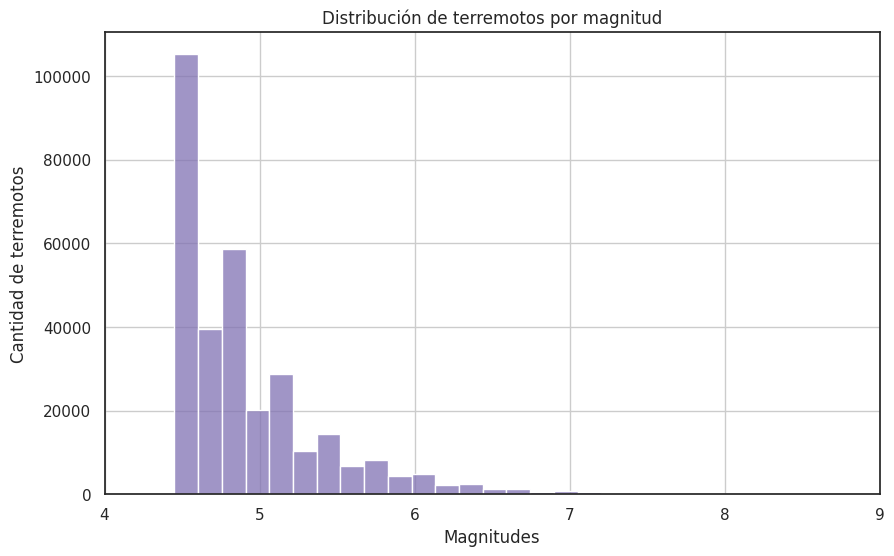

In [92]:
plt.figure(figsize = (10,6))
sns.histplot(data = terremotos, x = 'mag', bins = 40, color = 'm')

plt.xlabel('Magnitudes')
plt.xlim(4, 9)
plt.ylabel('Cantidad de terremotos')
plt.title('Distribución de terremotos por magnitud')
plt.grid(True)

plt.show()

Notemos que hay una clara tendencia entre los terremotos de baja magnitud, esto se puede deber a que hoy en día se analizan más con tecnología más precisa. Esta será nuestra hipotesis a desarrollar.

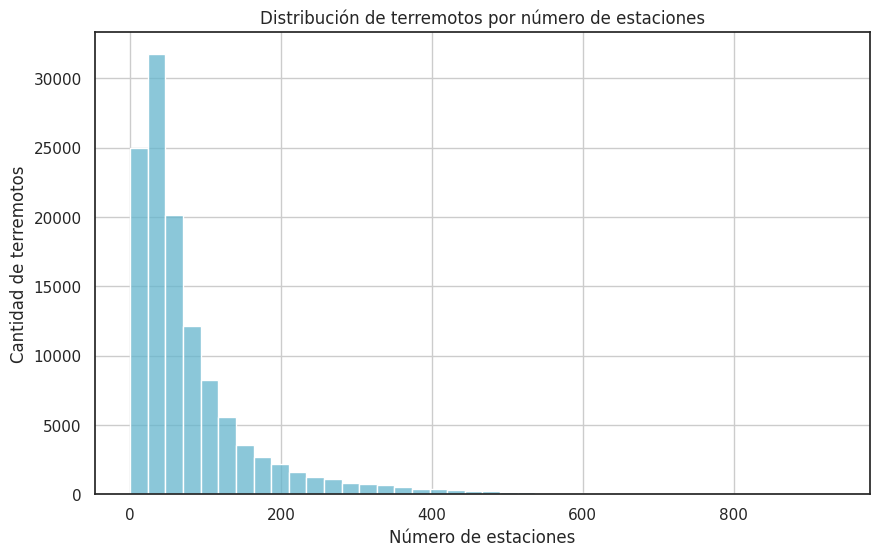

In [ ]:
plt.figure(figsize = (10,6))
sns.histplot(data = terremotos, x = 'nst', bins = 40, color = 'c')

plt.xlabel('Número de estaciones') #centros de mediciones en el mundo
plt.ylabel('Cantidad de terremotos')
plt.title('Distribución de terremotos por número de estaciones')
plt.grid(True)

plt.show()

Aquí se aprecia que la cantidad de estaciones que más miden terremotos son menores a 100, si analizamos la geografía de estas, nos daremos cuenta de que calzan con el grafico del mapamundi que se hará más adelante, o sea, las estaciones más cercanas a zonas con alta actividad sismica, tendrán más datos que una que esté más lejos.

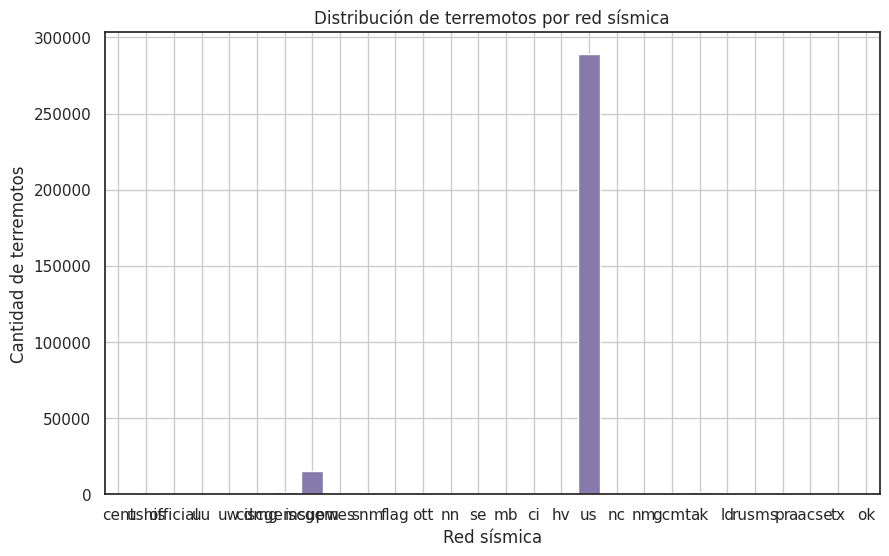

In [ ]:
plt.figure(figsize = (10,6))
sns.countplot(data = terremotos, x = 'net', color = 'm')

plt.xlabel('Red sísmica')
plt.ylabel('Cantidad de terremotos')
plt.title('Distribución de terremotos por red sísmica')
plt.grid(True)

plt.show()

Aquí notamos una gran disparidad de datos, por lo que esta rama se le ignorará para no obtener resultados o análisis erroneos.

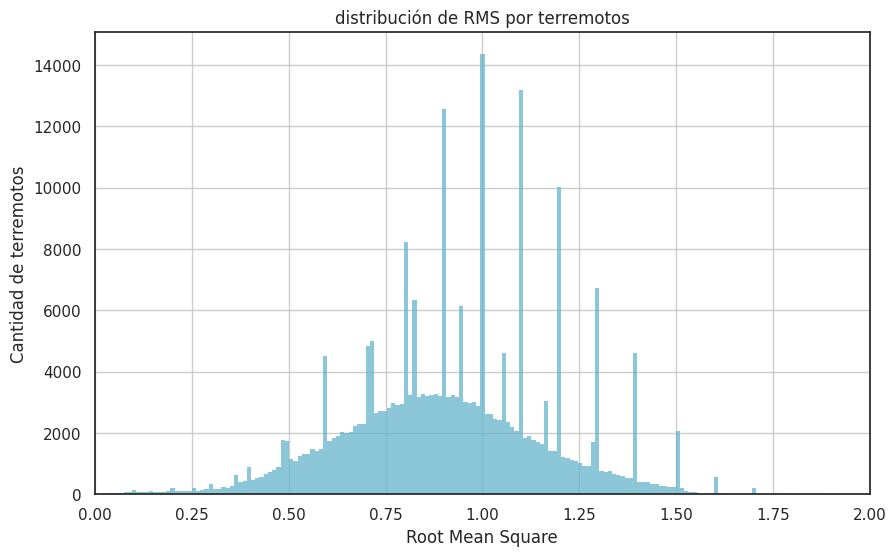

In [89]:
plt.figure(figsize = (10,6)) #rms es root mean square!
sns.histplot(data = terremotos, x = 'rms', color = 'c')

plt.xlabel('Root Mean Square')
plt.xlim(0, 2)
plt.ylabel('Cantidad de terremotos')
plt.title('distribución de RMS por terremotos')
plt.grid(True)

plt.show()

Este gráfico nos muestra una forma gausiana centrada en 1 donde se puede analizar alta volatilidad. Esto se medirá con respecto al tiempo para arreglarlo y analizarlo mejor.

In [ ]:
#fig = px.scatter_geo(terremotos, lat = 'latitude', lon = 'longitude', color = 'mag', title = 'Distribución de terremotos en el mundo')
#fig.show() #aquí llamamos la librería plotly.express para generar un mapamundi con los datos.
#Por su seguridad y la mía no le saque los gatos para volverlo comentario, lo dejo aquí y evidencio que hice en mi propio pc antes de escribir el notebook

Aquí no se pudo generar la figura, pero se adjuntara en github lo obtenido, tanto en imagen como en página. Así, ahora se aprecian fallas catactónicas y hasta el famoso circulo de fuego.

Ahora analizaremos las fechas para poder responder a la pregunta de estos datos.

In [64]:
terremotos['fechas'] = pd.to_datetime(terremotos['time']) #Generamos una columna con las fechas de la columna time
terremotos['años'] = terremotos['fechas'].dt.year #Generamos una columna con los años
print(terremotos['fechas'].head())
print(terremotos['años'].head())

0   1900-01-05 19:00:00+00:00
1   1900-01-11 09:07:00+00:00
2   1900-01-20 06:33:00+00:00
3   1900-01-31 19:22:00+00:00
4   1900-04-30 22:41:14+00:00
Name: fechas, dtype: datetime64[ns, UTC]
0    1900
1    1900
2    1900
3    1900
4    1900
Name: años, dtype: int32


/tmp/ipykernel_2775/449356225.py:1: UserWarning:

Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.



Analizamos el rms con respecto al tiempo para poder tener una idea de la evolución temporal de los sismógrafos.

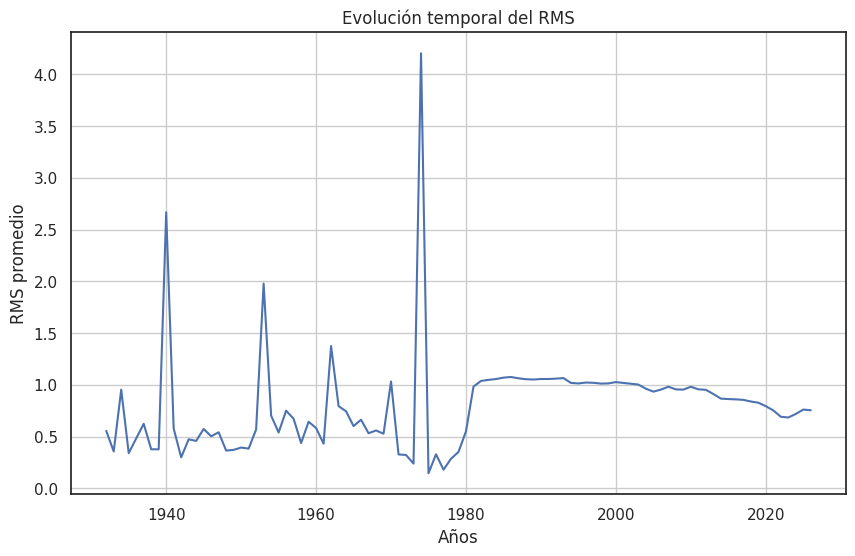

In [91]:
rms_por_año = terremotos.groupby('años')['rms'].agg(['mean', 'std', 'count']).reset_index()
plt.figure(figsize = (10, 6))
sns.lineplot(data = rms_por_año, x = 'años', y = 'mean')

plt.xlabel('Años')
plt.ylabel('RMS promedio')
plt.title('Evolución temporal del RMS')
plt.grid(True)

plt.show()

Con esto nos damos cuenta de la volatilidad que se tenía previo a los años 1980's diciéndonos que la calidad de las mediciones no eran óptimas para el tiempo, y a medida que progresó la técnología este se fue atenuando y corrigiendo, coincidiendo con el aumento de los terremotos bajo los 6 grados!

Ahora analizamos las magnitudes de estos para separarlos en 3 categorías

In [65]:
terremotos['mag_cat'] = pd.cut(terremotos['mag'], bins = [0, 6, 7, 10], labels = ['<6', '6-7', '>7']) #Generamos una columna con las 3 categorías.
conteo = terremotos.groupby(['años', 'mag_cat']).size().reset_index(name = 'cantidad') #Generamos el conteo en base a los años.

/tmp/ipykernel_2775/2497047227.py:2: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



Ahora trabajamos con las columnas nuevas

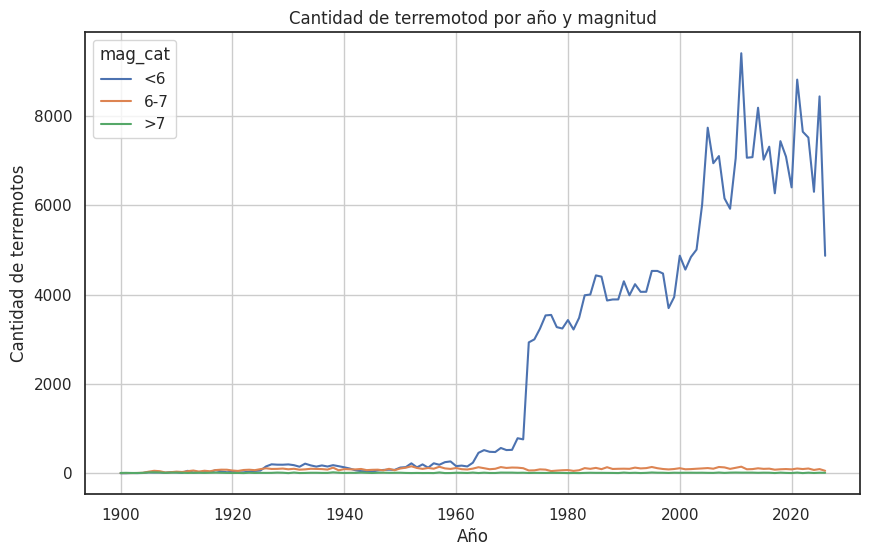

In [70]:
plt.figure(figsize = (10,6))
sns.lineplot(data = conteo, x = 'años', y = 'cantidad', hue ='mag_cat')
#Se eligió lineplot sobre pointplot debido a la distribución de los labels en el eje x.

plt.xlabel('Año')
plt.ylabel('Cantidad de terremotos')
plt.title('Cantidad de terremotod por año y magnitud')
plt.grid(True)

plt.show()

Aquí notamos una alza en las magnitudes >6° pero las lineas de tendencias restantes siguen igual, ahora veremos cómo se vé si solo tomamos magnitudes superiores a 6.
Notemos que esto se puede deber al avance de las preciciones de los instrumentos que aumentan año a año, pudiendo así detectar cada vez más.

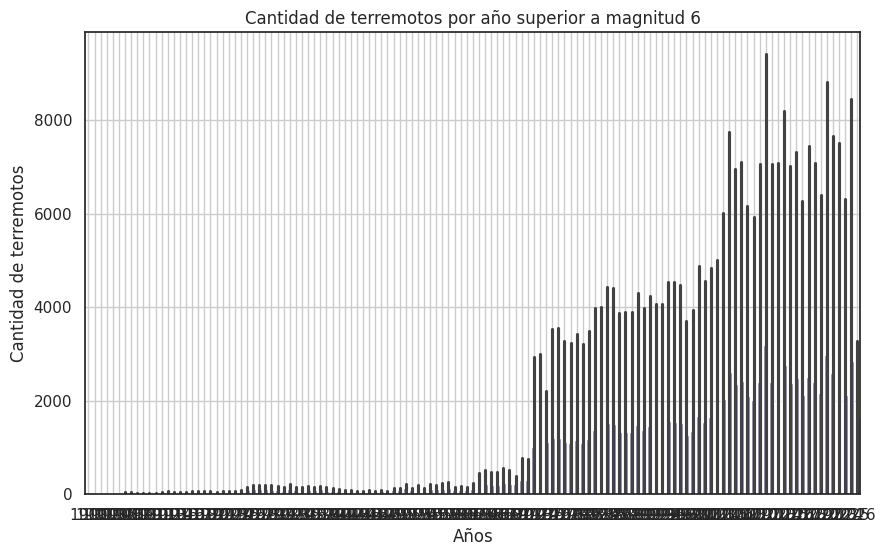

In [71]:
plt.figure(figsize = (10,6))
sns.barplot(data = conteo, x = 'años', y = 'cantidad', color = 'm')

plt.xlabel('Años')
plt.ylabel('Cantidad de terremotos')
plt.title('Cantidad de terremotos por año superior a magnitud 6')
plt.grid(True)

plt.show()

Este gráfico no lo arrreglo más porque me doy cuenta que arreglé mal la condición de mayor a 6 grados, por lo que intentaré hacerlo con un condición más de mayor a 7 grados.

In [80]:
terremotos_grandes = terremotos[terremotos['mag'] >= 7]
conteo_grandes = terremotos_grandes.groupby('años').size().reset_index(name = 'cantidad')

Con esto vemos el gráfico final:

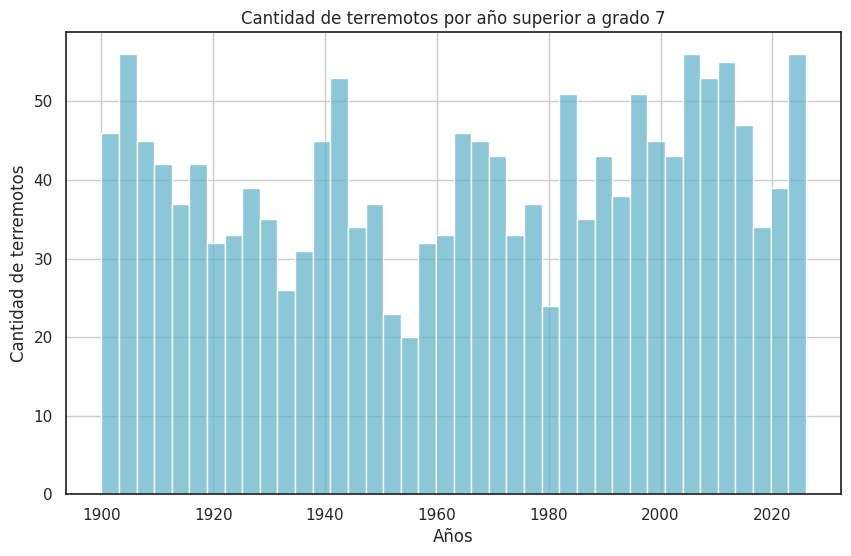

In [85]:
plt.figure(figsize = (10,6))
sns.histplot(data = conteo_grandes, x = 'años', weights = 'cantidad', bins = 40, color = 'c')

plt.xlabel('Años')
plt.ylabel('Cantidad de terremotos')
plt.title('Cantidad de terremotos por año superior a grado 7')
plt.grid(True)

plt.show()

Así podemos concluir que el aumento del registro de terremotos no es debido a que se generen más que antes, sino por el aumento de la sensibilidad de los intrumentos utilizados. Ademas se puede ver una tendencia de vaivén que calza con la acumulación y liberación de energía entre placas tectónicas.